# 01 — Data Overview
Quick look at the cleaned vaccination dataset.

In [1]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

OUT = os.path.join("..", "outputs")
os.makedirs(OUT, exist_ok=True)

In [2]:
with open(os.path.join("..", "data", "processed.pkl"), "rb") as f:
    df = pickle.load(f)

print(f"Shape: {df.shape}")
df.head()

Shape: (62980, 21)


,location,iso_code_x,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,total_boosters,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,...,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,daily_vaccinations_per_million,daily_people_vaccinated,daily_people_vaccinated_per_hundred,iso_code_y,vaccines,last_observation_date,source_name,source_website
78,Afghanistan,AFG,2021-05-11,504502.0,448878.0,55624.0,NaN,NaN,13921.0,1.23,...,0.14,NaN,338.0,10994.0,0.027,AFG,"CanSino, Covaxin, Johnson&Johnson, Moderna, Ox...",2023-12-31,World Health Organization,https://data.who.int/dashboards/covid19/
87,Afghanistan,AFG,2021-05-20,547901.0,470341.0,77560.0,NaN,NaN,4822.0,1.33,...,0.19,NaN,117.0,2385.0,0.006,AFG,"CanSino, Covaxin, Johnson&Johnson, Moderna, Ox...",2023-12-31,World Health Organization,https://data.who.int/dashboards/covid19/
91,Afghanistan,AFG,2021-05-24,573277.0,476367.0,96910.0,NaN,NaN,5692.0,1.39,...,0.24,NaN,138.0,1883.0,0.005,AFG,"CanSino, Covaxin, Johnson&Johnson, Moderna, Ox...",2023-12-31,World Health Organization,https://data.who.int/dashboards/covid19/
93,Afghanistan,AFG,2021-05-26,590454.0,479372.0,111082.0,NaN,NaN,6768.0,1.44,...,0.27,NaN,165.0,1631.0,0.004,AFG,"CanSino, Covaxin, Johnson&Johnson, Moderna, Ox...",2023-12-31,World Health Organization,https://data.who.int/dashboards/covid19/
94,Afghanistan,AFG,2021-05-27,593313.0,479574.0,113739.0,NaN,2859.0,6487.0,1.44,...,0.28,NaN,158.0,1319.0,0.003,AFG,"CanSino, Covaxin, Johnson&Johnson, Moderna, Ox...",2023-12-31,World Health Organization,https://data.who.int/dashboards/covid19/


## 1. df.info() & df.describe()

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62980 entries, 78 to 196245
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   location                             62980 non-null  object 
 1   iso_code_x                           62980 non-null  object 
 2   date                                 62980 non-null  object 
 3   total_vaccinations                   61995 non-null  float64
 4   people_vaccinated                    60382 non-null  float64
 5   people_fully_vaccinated              62980 non-null  float64
 6   total_boosters                       36513 non-null  float64
 7   daily_vaccinations_raw               49674 non-null  float64
 8   daily_vaccinations                   62665 non-null  float64
 9   total_vaccinations_per_hundred       61995 non-null  float64
 10  people_vaccinated_per_hundred        60382 non-null  float64
 11  people_fully_vaccinated_per_hun

In [4]:
df.describe()

,total_vaccinations,people_vaccinated,people_fully_vaccinated,total_boosters,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,daily_vaccinations_per_million,daily_people_vaccinated,daily_people_vaccinated_per_hundred
count,6.199500e+04,6.038200e+04,6.298000e+04,3.651300e+04,4.967400e+04,6.266500e+04,61995.000000,60382.000000,62980.000000,36513.000000,62665.000000,6.261700e+04,62617.000000
mean,7.829187e+07,3.684104e+07,3.104021e+07,1.745934e+07,1.504843e+05,1.267642e+05,126.014235,55.116888,48.370532,38.316995,2632.295508,5.144495e+04,0.100429
std,2.833924e+08,1.349014e+08,1.193870e+08,4.324220e+07,5.964743e+05,4.963357e+05,84.887681,28.835606,29.568390,31.996909,3422.443066,2.526482e+05,0.177586
min,6.900000e+01,4.700000e+01,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,1.750810e+06,8.795260e+05,6.933970e+05,4.847030e+05,1.326000e+03,1.191000e+03,50.450000,31.352500,20.497500,7.310000,255.000000,1.200000e+02,0.002000
50%,9.837452e+06,4.611138e+06,4.007586e+06,3.307067e+06,1.285250e+04,1.096300e+04,127.520000,64.340000,55.730000,35.810000,1387.000000,1.902000e+03,0.025000
75%,4.573327e+07,2.267288e+07,1.815635e+07,1.642882e+07,7.742200e+04,6.431800e+04,199.205000,79.460000,74.770000,61.630000,3815.000000,1.653100e+04,0.118000
max,3.491077e+09,1.310292e+09,1.276760e+09,8.269130e+08,1.862727e+07,1.307071e+07,410.230000,129.070000,126.890000,150.470000,84136.000000,6.785334e+06,3.535000


## 2. Null values heatmap

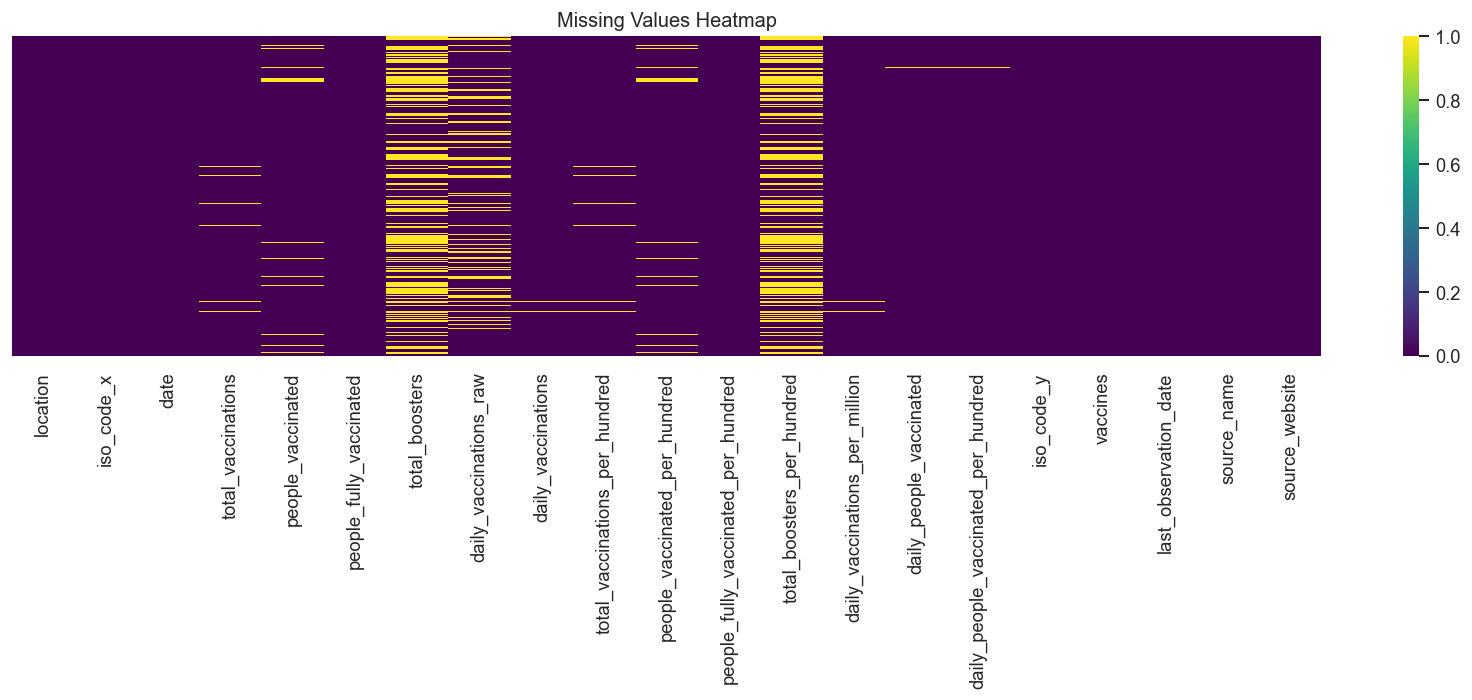

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap="viridis", ax=ax)
ax.set_title("Missing Values Heatmap")
fig.tight_layout()
fig.savefig(os.path.join(OUT, "null_heatmap.png"))
plt.show()

## 3. Top 15 countries by number of data points

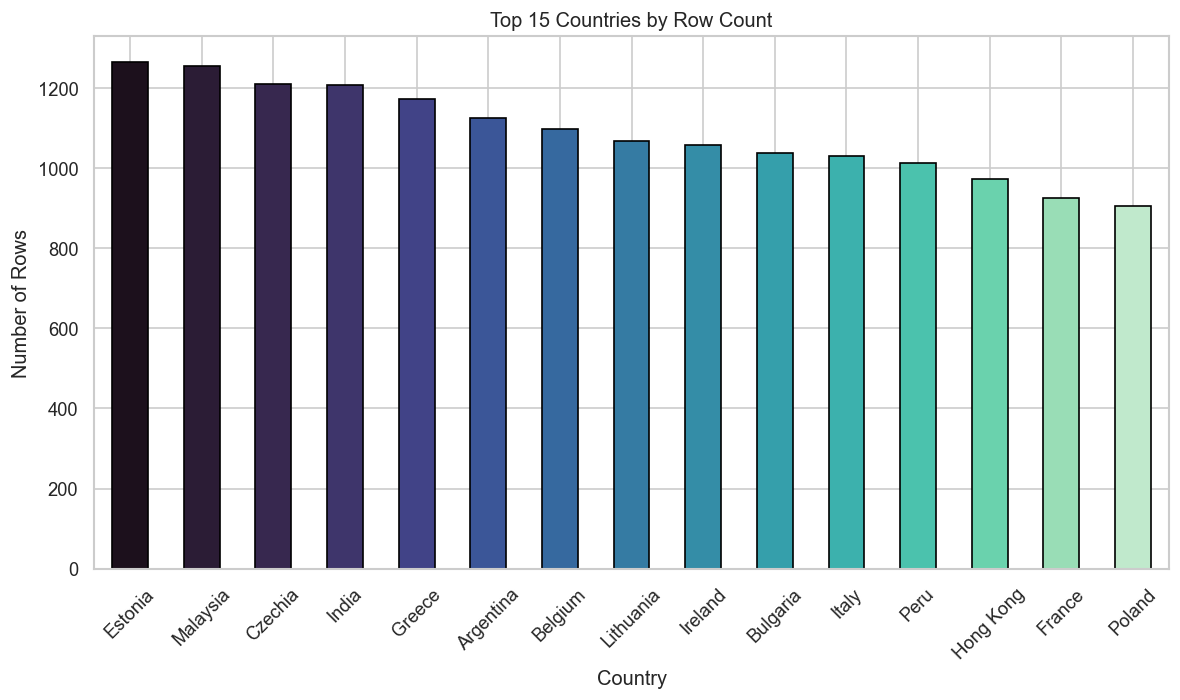

In [6]:
top15 = df["location"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top15.plot(kind="bar", color=sns.color_palette("mako", 15), edgecolor="black", ax=ax)
ax.set_title("Top 15 Countries by Row Count")
ax.set_xlabel("Country")
ax.set_ylabel("Number of Rows")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "top15_countries_bar.png"))
plt.show()

## 4. Date range coverage (top 20 countries)

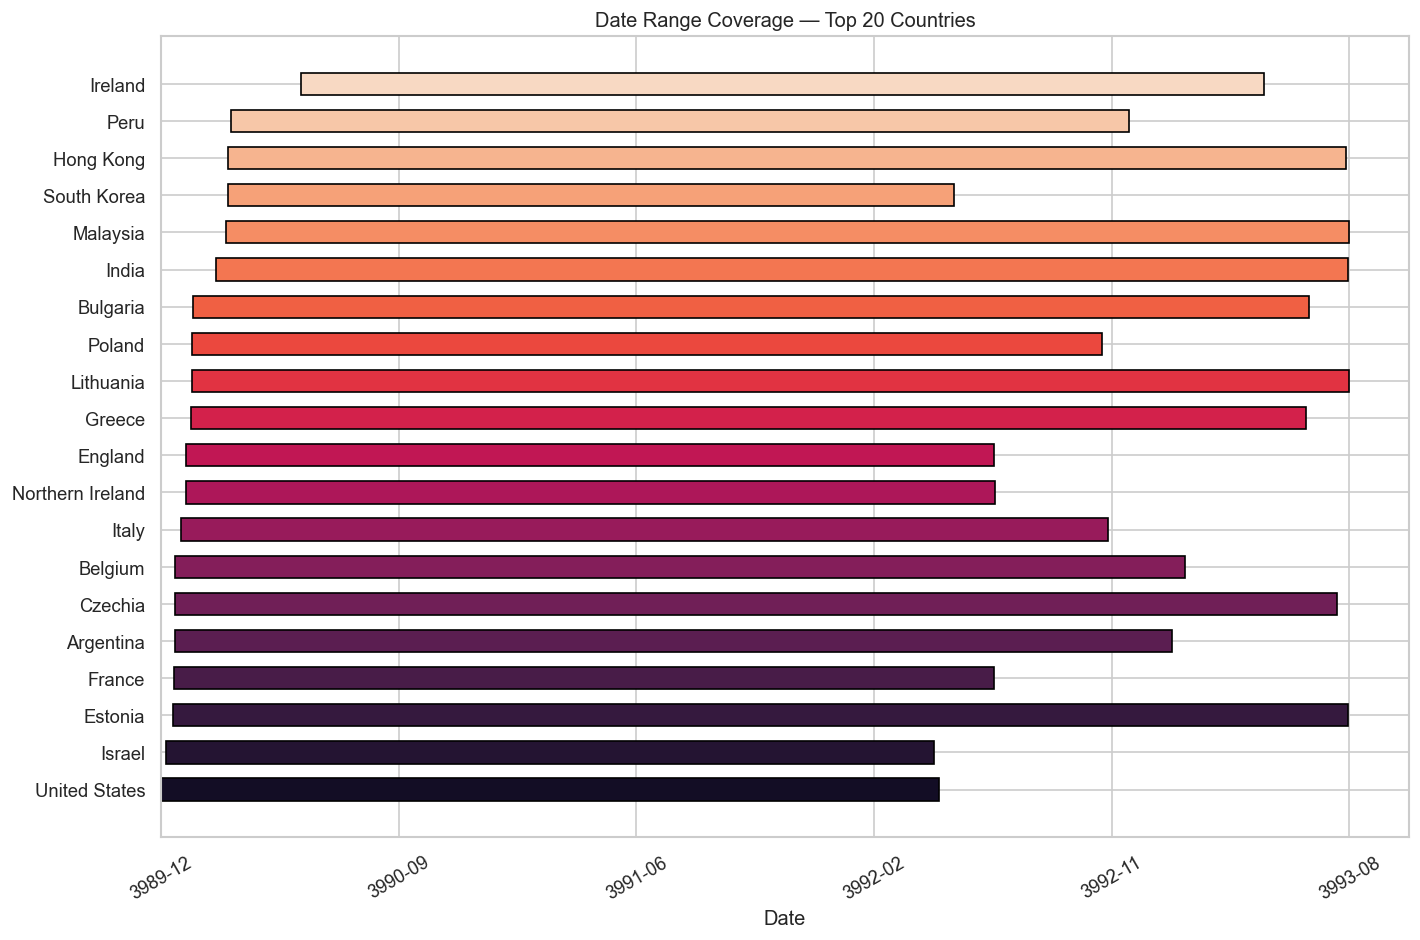

In [7]:
df["date"] = pd.to_datetime(df["date"])

# pick the 20 countries with most rows
top20 = df["location"].value_counts().head(20).index
sub = df[df["location"].isin(top20)]

date_range = (
    sub.groupby("location")["date"]
    .agg(["min", "max"])
    .sort_values("min")
)

fig, ax = plt.subplots(figsize=(12, 8))
for i, (country, row) in enumerate(date_range.iterrows()):
    ax.barh(i, (row["max"] - row["min"]).days, left=row["min"].toordinal(),
            color=sns.color_palette("rocket", 20)[i], edgecolor="black", height=0.6)

ax.set_yticks(range(len(date_range)))
ax.set_yticklabels(date_range.index)
ax.set_title("Date Range Coverage — Top 20 Countries")
ax.set_xlabel("Date")

# make x-axis show actual dates
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
xticks = pd.date_range(date_range["min"].min(), date_range["max"].max(), periods=6)
ax.set_xticks([d.toordinal() for d in xticks])
ax.tick_params(axis="x", rotation=30)

fig.tight_layout()
fig.savefig(os.path.join(OUT, "date_range_coverage.png"))
plt.show()

## 5. Top 5 most common vaccines

In [8]:
# each row in 'vaccines' is like "Pfizer/BioNTech, Oxford/AstraZeneca"
# split them out and count individually
all_vaccines = df["vaccines"].dropna().str.split(", ").explode()
top5 = all_vaccines.value_counts().head(5)

print("Top 5 most common vaccines (by country-day appearances):")
print(top5.to_string())

Top 5 most common vaccines (by country-day appearances):
vaccines
Pfizer/BioNTech       57096
Oxford/AstraZeneca    53321
Moderna               42059
Johnson&Johnson       32669
Sinopharm/Beijing     21251
